## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [40]:
# Import the relevant libraries with their aliases

# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler



In [41]:
# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Add your code here:

# Load the Boston Housing dataset

boston = fetch_openml(name="boston", version=1, as_frame=True)

df = boston.frame

# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [42]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
print(df.info())

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 48.6 KB
None
             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.554695    6.2

In [44]:
'''
The target variable (MEDV) is numerical, so this dataset is suitable for a regression model.


The maximum values of variables such as the crime rate by town (CRIM) and 
the proportion of residential land zoned for large lots (ZN) are much higher than their means and quartiles, 
suggesting that these variables may contain outliers.
'''

'\nThe target variable (MEDV) is numerical, so this dataset is suitable for a regression model.\n\n\nThe maximum values of variables such as the crime rate by town (CRIM) and \nthe proportion of residential land zoned for large lots (ZN) are much higher than their means and quartiles, \nsuggesting that these variables may contain outliers.\n'

In [45]:

# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
print(df.shape)

print(df.isnull().sum())

(506, 14)
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [46]:
'''
The dataset consists of 506 observations and 14 columns, with no missing values.
'''

'\nThe dataset consists of 506 observations and 14 columns, with no missing values.\n'

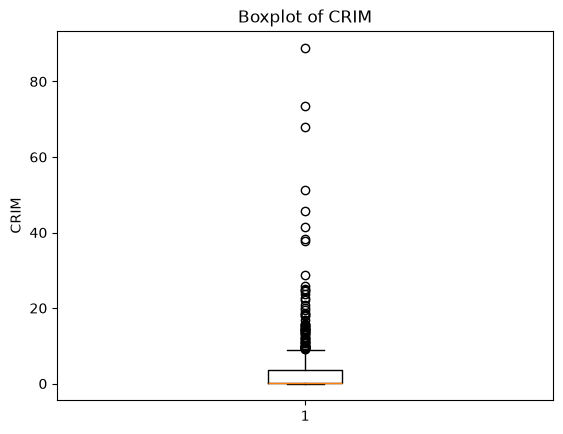

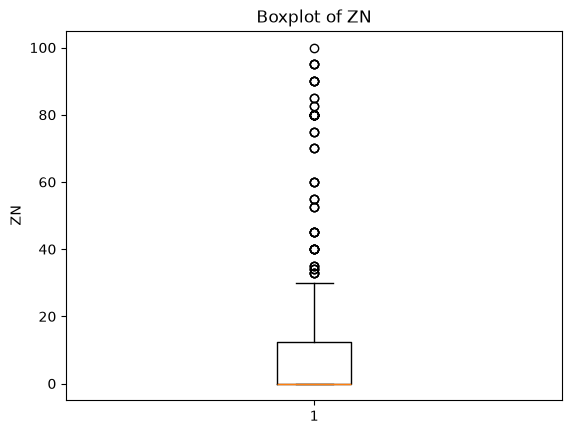

In [47]:
# Checking outliers

# Boxplot for CRIM
plt.boxplot(df['CRIM'])
plt.title('Boxplot of CRIM')
plt.ylabel('CRIM')
plt.show()

# Boxplot for ZN
plt.boxplot(df['ZN'])
plt.title('Boxplot of ZN')
plt.ylabel('ZN')
plt.show()

In [48]:
# Handle Missing values
variables = ['CRIM', 'ZN']

for col in variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].map(
        lambda x: Q1 if x < lower_bound else Q3 if x > upper_bound else x
    )

In [49]:
df[['CRIM', 'ZN']].describe()

,CRIM,ZN
count,506.000000,506.000000
mean,1.521655,4.443676
std,2.152988,7.939392
min,0.006320,0.000000
25%,0.082045,0.000000
50%,0.256510,0.000000
75%,3.676229,12.500000
max,8.982960,30.000000


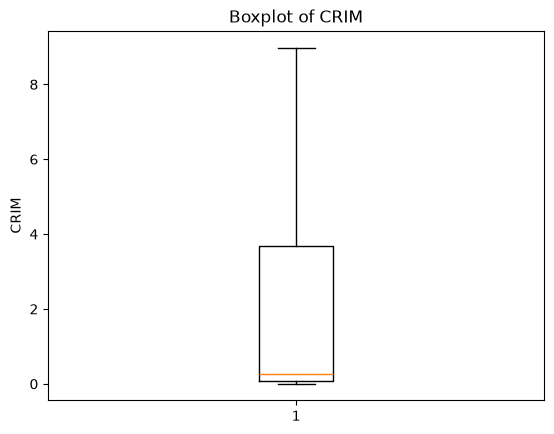

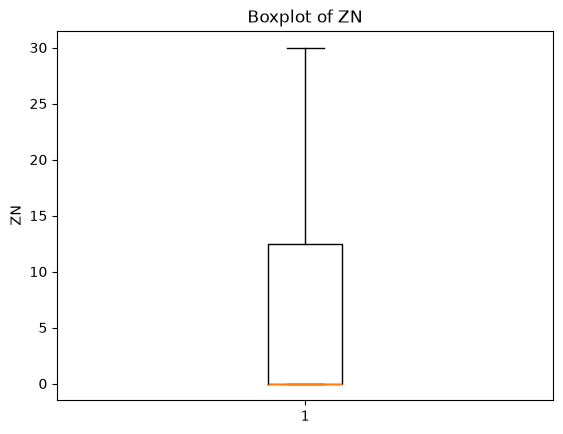

In [50]:
# Checking outliers

# Boxplot for CRIM
plt.boxplot(df['CRIM'])
plt.title('Boxplot of CRIM')
plt.ylabel('CRIM')
plt.show()

# Boxplot for ZN
plt.boxplot(df['ZN'])
plt.title('Boxplot of ZN')
plt.ylabel('ZN')
plt.show()

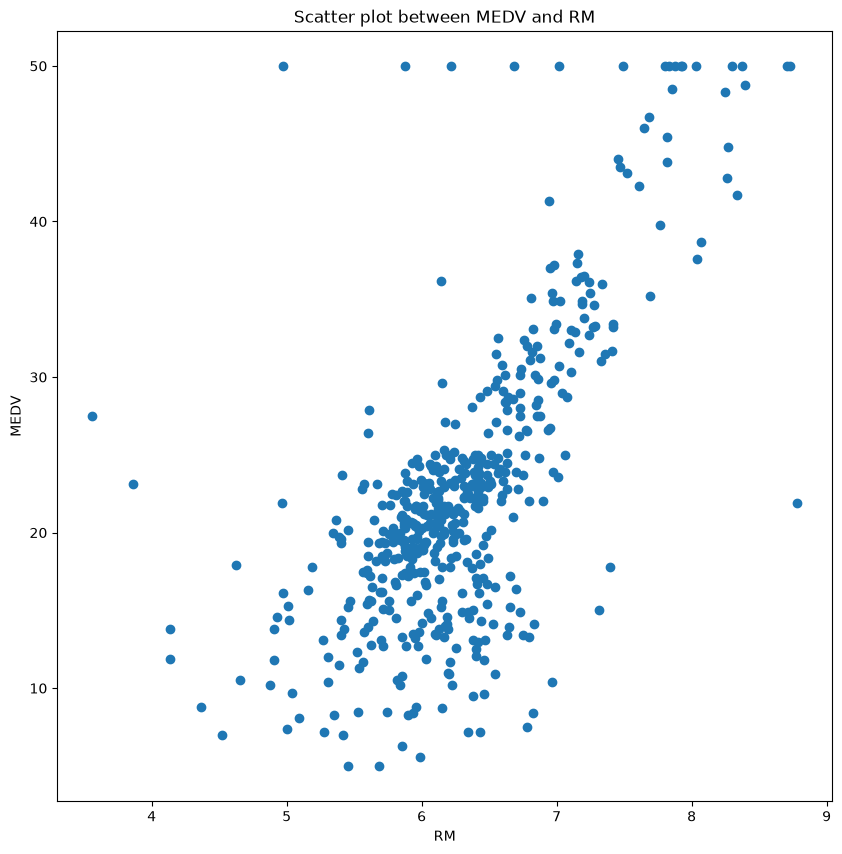

In [51]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').

# Add your code here:
# Display scatter plot between 'MedInc' and 'MedHouseVal'
plt.figure(figsize=(10, 10))

plt.scatter(df['RM'],df['MEDV'])
plt.title('Scatter plot between MEDV and RM')
plt.xlabel('RM')
plt.ylabel('MEDV')

plt.show()

In [52]:
# Calculating correlation between RM and MEDV

#print(corr(df['MEDV'],df['RM']))
df["RM"].corr(df["MEDV"])

np.float64(0.6953599470715395)

In [53]:
'''
The scatter plot shows a strong positive linear relationship between RM and MEDV. The correlation coefficient is approximately 0.695 (69.5%), 
indicating that homes with a higher average number of rooms per dwelling tend to have higher median values.

'''

'\nThe scatter plot shows a strong positive linear relationship between RM and MEDV. The correlation coefficient is approximately 0.695 (69.5%), \nindicating that homes with a higher average number of rooms per dwelling tend to have higher median values.\n\n'

In [54]:
# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:

# Define your function here:
def plot_features(df, features):
    for feature in features:
        plt.figure(figsize=(7, 5))
        
        plt.scatter(df[feature], df['MEDV'])
        
        plt.xlabel(feature)
        plt.ylabel('MEDV')
        plt.title(f'Scatter plot between {feature} and MEDV')
        
        plt.show()

In [55]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


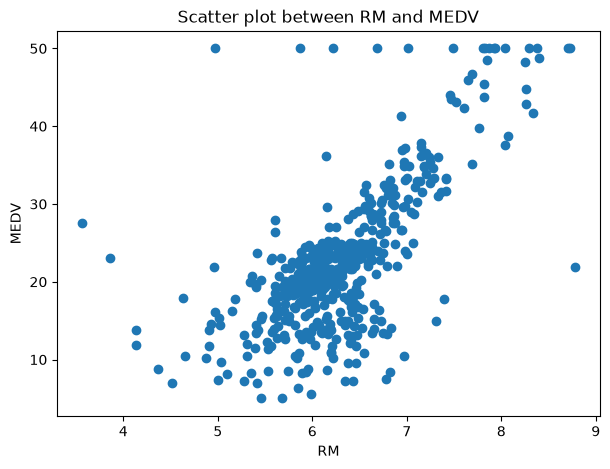

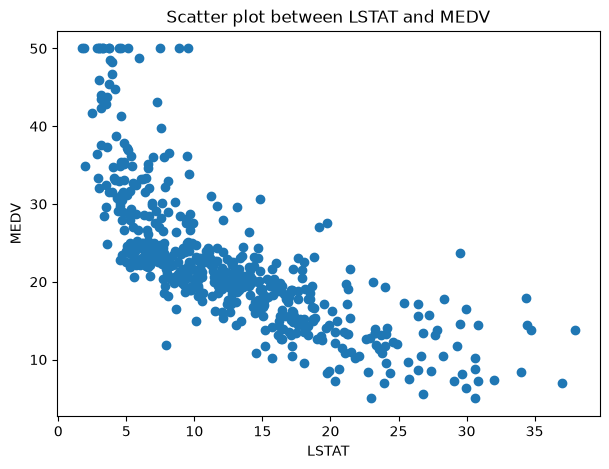

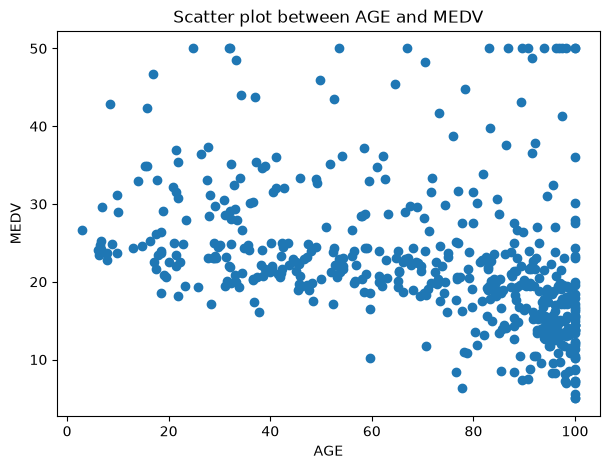

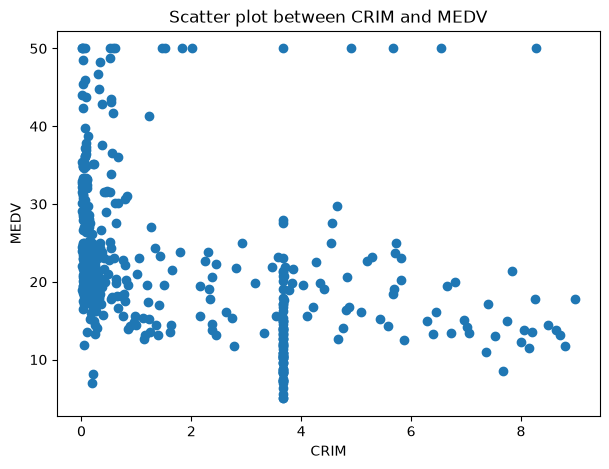

In [56]:

# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Example: ['RM', 'LSTAT', 'AGE', 'CRIM']
# Target: 'MEDV'

# Add your code here:
features = df[['RM', 'LSTAT', 'AGE', 'CRIM']]

plot_features(df, features)


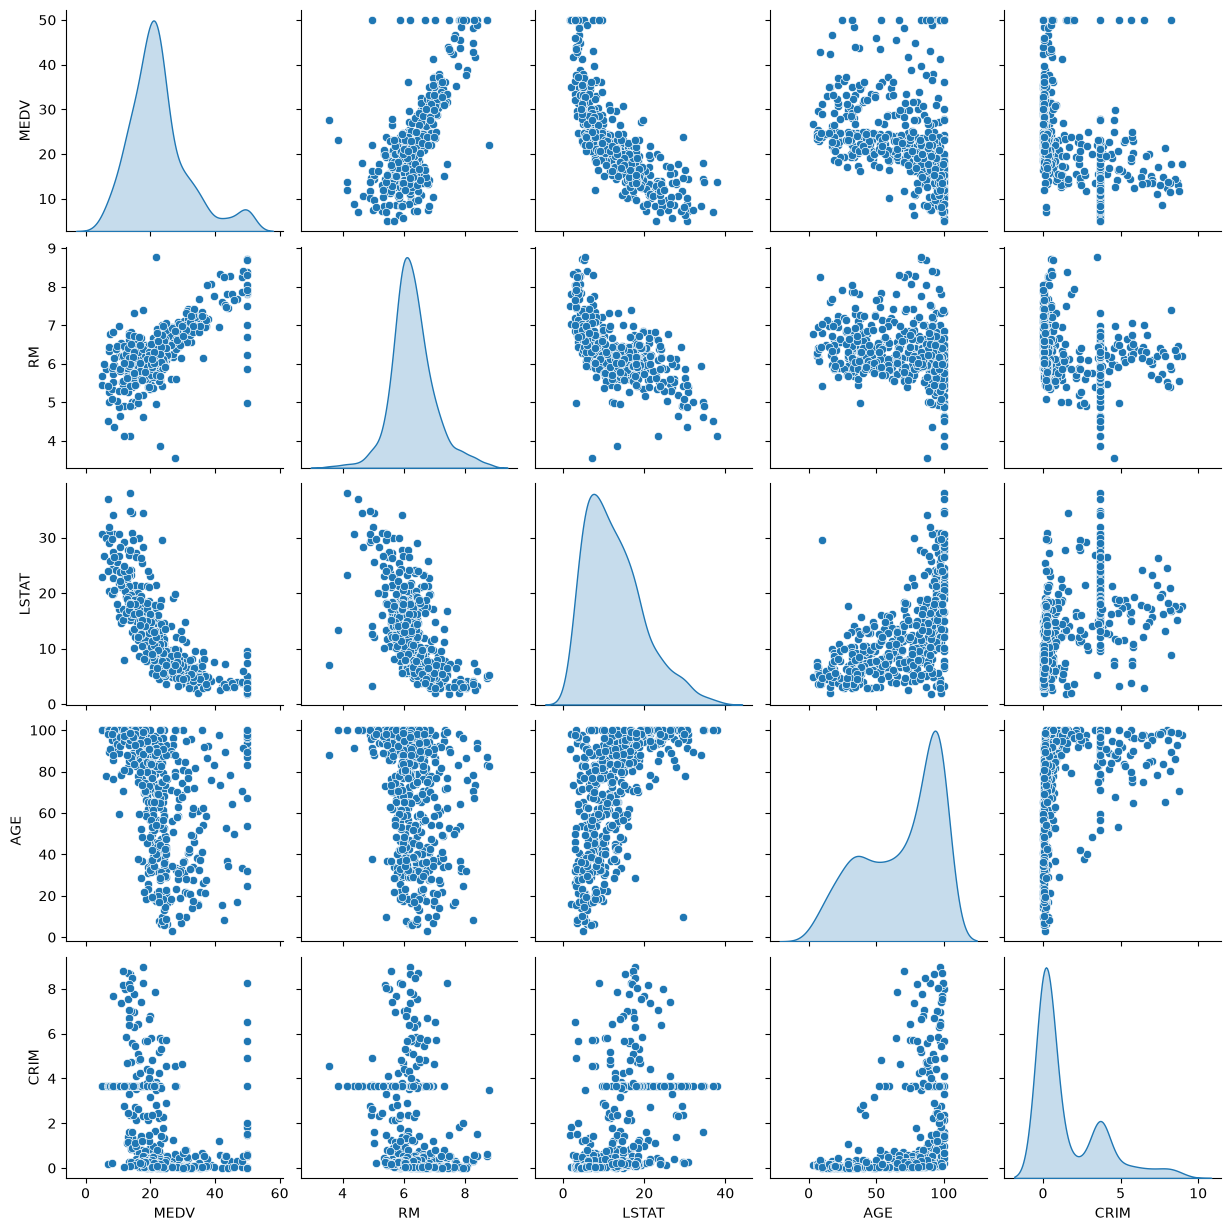

In [57]:
features = df[['MEDV','RM', 'LSTAT', 'AGE', 'CRIM']]

sns.pairplot(features,diag_kind='kde')

In [59]:
'''
According to the plots, there is a negative relationship between MEDV and both LSTAT and AGE. 
There is no clear pattern between MEDV and CRIM. However, higher CRIM values appear to be associated with lower MEDV values, 
suggesting that areas with higher crime rates tend to have lower median home values.

'''

'\nAccording to the plots, there is a negative relationship between MEDV and both LSTAT and AGE. \nThere is no clear pattern between MEDV and CRIM. However, higher CRIM values appear to be associated with lower MEDV values, \nsuggesting that areas with higher crime rates tend to have lower median home values.\n\n'

In [60]:
# Select categorical variables
categorical_cols = df.select_dtypes(include='category').columns

# Display categorical variables
print(categorical_cols)

# Summary of each categorical variable
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

Index(['CHAS', 'RAD'], dtype='str')

CHAS
CHAS
0    471
1     35
Name: count, dtype: int64

RAD
RAD
24    132
5     115
4     110
3      38
6      26
2      24
8      24
1      20
7      17
Name: count, dtype: int64


In [75]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
x = np.array(df.drop(columns=["MEDV"])) 
y = np.array(df["MEDV"])

In [ ]:
# Model 1 : Decision Tree

In [76]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(x_train, y_train)

print(dt_model.score(x_test, y_test))

0.7895243910421958


In [65]:
# Perform parameter tuning on the model if needed to improve the performance of your model.

# Add your parameter tuning code here:

from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

# Grid Search
grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit the model
grid_search_dt.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search_dt.best_params_)

# Best model
best_dt_model = grid_search_dt.best_estimator_



Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [66]:
# print score using the best model 

print(best_dt_model.score(x_test, y_test))

0.8236403000639342


In [68]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics: # 0.7895243910421958

# Make predictions using the best model 
y_pred_dt = best_dt_model.predict(x_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred_dt)

# Calculate R² score
r2 = r2_score(y_test, y_pred_dt)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


Mean Squared Error: 17.505491600855926
R² Score: 0.8236403000639342


In [ ]:
'''
The initial model achieved an R² score of 0.78. After hyperparameter optimization, 
the R2 score increased to 0.82, indicating an improvement in the model's predictive performance.

The mean squared error (MSE) is low, approximately 17.5.
'''

In [78]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
#
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

# Add your prediction code here:

features = np.array([[0.2, 12.5, 7.07, 0, 0.5, 6.5, 68, 4.0, 2, 250, 17, 400, 12]])
print(best_dt_model.predict(features))

[21.35434783]


In [ ]:
Example new observations:
CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

For the given set of characteristics, the Decision Tree Regressor predicts a median house value of $21,354.

In [77]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
# Model 2 : Random Forest

In [80]:
# Perform parameter tuning on the model if needed to improve the performance of your model.

# Add your parameter tuning code here:

from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit the model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Best model
best_rf_model = grid_search.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [81]:
# print score using the best model 

print(best_rf_model.score(x_test, y_test))

0.8556544551189289


In [84]:
'''
Conclusion
The Random Forest Regressor achieved a lower MSE (14.33) and a higher R² score (0.856) compared with 
the Decision Tree Regressor, which achieved an MSE of 17.51 and an R² score of 0.824.

Therefore, the Random Forest model performs better because it has lower prediction error 
and explains a larger proportion of the variability in house prices. 

With Random Forest, 85.6% of the variation in MEDV is explained by the model.
'''

'\nConclusion\n\n'

In [85]:
# --- Random Forest Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
#
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

# Add your prediction code here:

features = np.array([[0.2, 12.5, 7.07, 0, 0.5, 6.5, 68, 4.0, 2, 250, 17, 400, 12]])
print(best_rf_model.predict(features))

[22.834]


In [ ]:
# Prediction result

CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

For the given set of characteristics, the Decision Tree Regressor predicts a median house value of $21,300, 
while the Random Forest Regressor predicts $22,834. Since the Random Forest was the best-performing model, 
its prediction of $22,834 can be considered the preferred estimate.

In [83]:
# --- Random Forest Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics: # 0.7895243910421958

# Make predictions using the best model 
y_pred_rf = best_rf_model.predict(x_test)

# Calculate Mean Squared Error
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate R² score
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Squared Error: {mse_rf}")
print(f"R² Score: {r2_rf}")


Mean Squared Error: 14.327761526315788
R² Score: 0.8556544551189289


In [ ]:


# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:


# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Add your code here:


# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:


# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:


# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:


# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').

# Add your code here:


# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:


# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Example: ['RM', 'LSTAT', 'AGE', 'CRIM']
# Target: 'MEDV'

# Add your code here:


# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:


# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Hint: Use either `DecisionTreeRegressor` or `RandomForestRegressor` from `sklearn.tree` or `sklearn.ensemble`.

# Define your regression model here:


# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:


# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Perform parameter tuning on the model if needed to improve the performance of your model.

# Add your parameter tuning code here:

# Predict on the test set and calculate the evaluation metrics:


# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
#
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

# Add your prediction code here:



